In [3]:
#@title # Model #2: 1D (ESM-2 embedding) + Random Forest
# =============================================================================
# Part of the InterPET ablation table:
#   1. 1D, ESM-2, XGBoost   (already done)
#   2. 1D, ESM-2, RF        <- this notebook
#   3. 1D, ProtT5, XGBoost
#   4. 1D, ProtT5, RF
#   5. 1D, AAC/CTD, XGBoost
#   6. 1D, AAC/CTD, RF
#   7. 1D, Graph (chain edges), GraphSAGE
#   8. 1D+3D, Graph (structure contact-map edges), GraphSAGE
#
# Model #2 uses the exact same input representation as Model #1 (ESM-2
# mean-pooled embeddings) -- the only difference is the classifier: Random
# Forest replaces XGBoost. This is a pure ablation on classifier choice, so
# every other part of the methodology (CV, threshold from OOF, single
# benchmark evaluation, metrics, SHAP, mutagenesis scan) is kept identical
# to Model #1 for a fair apples-to-apples comparison.

In [4]:
#@title # Mount Google Drive & Install dependencies
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers accelerate scikit-learn pandas numpy shap tqdm seaborn

Mounted at /content/drive


In [5]:
#@title # 1. Configuration

import os
import time
import numpy as np
import pandas as pd
import torch
import pickle

PROJECT_ROOT = "/content/drive/MyDrive/InterPET"
DATASETS_DIR = os.path.join(PROJECT_ROOT, "datasets")
MODEL_OUT_DIR = os.path.join(PROJECT_ROOT, "models", "model2_esm2_rf")
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

# Model #1 output directory -- used to reuse the already-computed ESM-2
# embeddings (Model #1 and #2 share the exact same input representation,
# so there is no need to re-run the expensive ESM-2 inference).
MODEL1_OUT_DIR = os.path.join(PROJECT_ROOT, "models", "model1_esm2_xgb")

TRAIN_FINAL_CSV = os.path.join(DATASETS_DIR, "train_final_labels.csv")
BENCHMARK_FINAL_CSV = os.path.join(DATASETS_DIR, "benchmark_final_labels.csv")

ESM2_MODEL_NAME = "facebook/esm2_t30_150M_UR50D"
N_FOLDS = 5
RANDOM_SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

np.random.seed(RANDOM_SEED)

for path in [TRAIN_FINAL_CSV, BENCHMARK_FINAL_CSV]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found. Run the Dataset Curation & QC notebook first.")

Device: cuda


In [6]:
#@title # 2. Load curated dataset

df_train = pd.read_csv(TRAIN_FINAL_CSV)
df_bench = pd.read_csv(BENCHMARK_FINAL_CSV)

print(f"Train: {len(df_train)} sequences ({df_train['label'].sum()} positive, {(df_train['label']==0).sum()} negative)")
print(f"Benchmark: {len(df_bench)} sequences ({df_bench['label'].sum()} positive, {(df_bench['label']==0).sum()} negative)")

Train: 937 sequences (403 positive, 534 negative)
Benchmark: 139 sequences (22 positive, 117 negative)


In [7]:
#@title # Resume from checkpoint (skip embedding extraction + training)
# Run this INSTEAD of sections 3-6 (embedding extraction, hyperparameter
# search, threshold optimization, final model training) if those already
# ran once before and you only want to redo visualization / interpretability
# (section 7 onward) -- e.g. after a runtime restart, or when just tweaking
# plotting/analysis code. Sections "Mount + Install", "1. Configuration",
# and "2. Load curated dataset" still need to run first (for df_train,
# df_bench, MODEL_OUT_DIR, etc).

import json
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score, average_precision_score,
    confusion_matrix, accuracy_score, matthews_corrcoef,
)

# Embeddings: prefer this model's own saved copy; fall back to Model #1's
# cache if this model never saved one (e.g. checkpoint taken before the
# "always save a local copy" fix was added to section 3).
def _load_embeddings(filename):
    local_path = os.path.join(MODEL_OUT_DIR, filename)
    if os.path.exists(local_path):
        return np.load(local_path)
    fallback_path = os.path.join(MODEL1_OUT_DIR, filename)
    if os.path.exists(fallback_path):
        return np.load(fallback_path)
    raise FileNotFoundError(f"Could not find {filename} in either {MODEL_OUT_DIR} or {MODEL1_OUT_DIR}.")

X_train_full = _load_embeddings("X_train_esm2.npy")
X_bench = _load_embeddings("X_bench_esm2.npy")
y_train_full = df_train["label"].astype(int).to_numpy()
y_bench = df_bench["label"].astype(int).to_numpy()

with open(os.path.join(MODEL_OUT_DIR, "best_params.json")) as f:
    best_params = json.load(f)

with open(os.path.join(MODEL_OUT_DIR, "chosen_threshold.txt")) as f:
    best_threshold = float(f.read())

with open(os.path.join(MODEL_OUT_DIR, "final_model.pkl"), "rb") as f:
    final_model = pickle.load(f)

oof_proba = np.load(os.path.join(MODEL_OUT_DIR, "oof_proba.npy"))
y_bench_proba = np.load(os.path.join(MODEL_OUT_DIR, "y_bench_proba.npy"))
y_bench_pred = np.load(os.path.join(MODEL_OUT_DIR, "y_bench_pred.npy"))

bench_metrics = pd.read_csv(
    os.path.join(MODEL_OUT_DIR, "benchmark_metrics.csv"), index_col=0
).squeeze("columns").to_dict()

# Needed by later sections (e.g. "11. Per-fold metrics") that call
# build_rf(best_params) -- normally defined in section 4, skipped here.
def build_rf(params):
    base = RandomForestClassifier(
        **params, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1,
    )
    return CalibratedClassifierCV(base, method="sigmoid", cv=3)

# Deterministic given the same random_state, so this reproduces the exact
# same folds without retraining anything.
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Cheap to recompute from oof_proba (no retraining involved) -- needed for
# the "F1 vs threshold" plot in section 10.
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_train_full, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds]
oof_pred = (oof_proba >= best_threshold).astype(int)

# Needed later for the ESM-2 embedding calls in the mutagenesis sections
if "esm2_model" not in dir():
    from transformers import AutoTokenizer, EsmModel
    esm2_tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_NAME)
    esm2_model = EsmModel.from_pretrained(ESM2_MODEL_NAME).to(device).eval()

print("Checkpoint loaded -- ready to jump to section 7 (visualization & interpretability).")
print(f"X_train_full: {X_train_full.shape}, X_bench: {X_bench.shape}")
print(f"best_params: {best_params}")
print(f"best_threshold: {best_threshold:.2f}")
print("Benchmark metrics:", bench_metrics)

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  595MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Checkpoint loaded -- ready to jump to section 7 (visualization & interpretability).
X_train_full: (937, 640), X_bench: (139, 640)
best_params: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
best_threshold: 0.31
Benchmark metrics: {'accuracy': 0.9136690647482014, 'precision': 0.6470588235294118, 'recall': 1.0, 'f1': 0.7857142857142857, 'auc': 0.9848484848484848, 'pr_auc': 0.8745486410949155, 'mcc': 0.7620326869550503}


In [ ]:
#@title # 3. Extract ESM-2 embeddings (mean-pooled) -- reuse Model #1 cache if available

from transformers import AutoTokenizer, EsmModel

cached_train_path = os.path.join(MODEL1_OUT_DIR, "X_train_esm2.npy")
cached_bench_path = os.path.join(MODEL1_OUT_DIR, "X_bench_esm2.npy")

if os.path.exists(cached_train_path) and os.path.exists(cached_bench_path):
    print("Found cached embeddings from Model #1 -- reusing them directly (no need to re-run ESM-2).")
    X_train_full = np.load(cached_train_path)
    X_bench = np.load(cached_bench_path)
    y_train_full = df_train["label"].astype(int).to_numpy()
    y_bench = df_bench["label"].astype(int).to_numpy()
    print(f"X_train_full: {X_train_full.shape}, X_bench: {X_bench.shape}")

    # Also save a local copy in THIS model's own output dir, so the
    # checkpoint / resume cell later doesn't need to know whether the
    # embeddings originally came from cache or were freshly computed.
    np.save(os.path.join(MODEL_OUT_DIR, "X_train_esm2.npy"), X_train_full)
    np.save(os.path.join(MODEL_OUT_DIR, "X_bench_esm2.npy"), X_bench)
else:
    print("Model #1 cache not found -- computing ESM-2 embeddings from scratch.")
    print(f"Loading {ESM2_MODEL_NAME}...")
    esm2_tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_NAME)
    esm2_model = EsmModel.from_pretrained(ESM2_MODEL_NAME).to(device).eval()

    @torch.no_grad()
    def get_embeddings(sequences, batch_size=8, max_len=1022):
        embs = []
        for i in range(0, len(sequences), batch_size):
            batch = [s[:max_len] for s in sequences[i:i + batch_size]]
            inputs = esm2_tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=max_len + 2)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            out = esm2_model(**inputs)
            mask = inputs["attention_mask"].unsqueeze(-1)
            mean_pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
            embs.append(mean_pooled.cpu().numpy())
            if (i // batch_size + 1) % 50 == 0:
                print(f"    {i + len(batch)}/{len(sequences)}")
        return np.vstack(embs)

    t0 = time.time()
    print("\nComputing training set embeddings...")
    X_train_full = get_embeddings(df_train["sequence"].tolist())
    y_train_full = df_train["label"].astype(int).to_numpy()
    print(f"Done ({(time.time()-t0)/60:.1f} min). Shape: {X_train_full.shape}")

    t0 = time.time()
    print("\nComputing benchmark set embeddings...")
    X_bench = get_embeddings(df_bench["sequence"].tolist())
    y_bench = df_bench["label"].astype(int).to_numpy()
    print(f"Done ({(time.time()-t0)/60:.1f} min). Shape: {X_bench.shape}")

    np.save(os.path.join(MODEL_OUT_DIR, "X_train_esm2.npy"), X_train_full)
    np.save(os.path.join(MODEL_OUT_DIR, "X_bench_esm2.npy"), X_bench)

    esm2_tokenizer_ref, esm2_model_ref = esm2_tokenizer, esm2_model

# If embeddings were reused from cache, we still need esm2_tokenizer & esm2_model
# (used later in the mutagenesis scan section) -- load them if not already in memory.
if "esm2_model" not in dir():
    print("Loading ESM-2 model/tokenizer (needed later for the mutagenesis scan)...")
    esm2_tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_NAME)
    esm2_model = EsmModel.from_pretrained(ESM2_MODEL_NAME).to(device).eval()

Found cached embeddings from Model #1 -- reusing them directly (no need to re-run ESM-2).
X_train_full: (937, 640), X_bench: (139, 640)
Loading ESM-2 model/tokenizer (needed later for the mutagenesis scan)...


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  595MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#@title # 4. Hyperparameter search (Stratified K-Fold CV) -- Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

# FIX (RF probability quantization issue):
# Plain RandomForestClassifier.predict_proba() averages hard per-tree class
# votes. With min_samples_leaf=1, many leaves are "pure" (single sample), so
# each tree's output is essentially 0/1 rather than a fraction. That makes
# predict_proba a coarse step function -- tiny input perturbations (like a
# single mean-pooled-embedding shift from one residue mutation) either do
# nothing at all, or flip a large block of correlated trees at once, causing
# ties like several very different residues all showing delta_proba exactly
# 0.5 in the mutagenesis scan.
#
# Two changes address this:
#   1. min_samples_leaf is raised (>=3) in the grid below, so leaves contain
#      more samples and produce fractional (smoother) per-tree probabilities.
#   2. The RF is wrapped in CalibratedClassifierCV (Platt/sigmoid scaling),
#      which recalibrates the probability output into a smooth, continuous
#      curve. This wrapper is used consistently everywhere in this notebook
#      (hyperparameter search, OOF threshold, final model, per-fold metrics)
#      so results stay comparable across all steps.

def build_rf(params):
    base = RandomForestClassifier(
        **params, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1,
    )
    return CalibratedClassifierCV(base, method="sigmoid", cv=3)

param_grid = [
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 3,  "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 10,   "min_samples_leaf": 5,  "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": 20,   "min_samples_leaf": 3,  "max_features": "log2"},
    {"n_estimators": 500, "max_depth": None, "min_samples_leaf": 8,  "max_features": "sqrt"},
    {"n_estimators": 800, "max_depth": 15,   "min_samples_leaf": 10, "max_features": "log2"},
]

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

n_pos = y_train_full.sum()
n_neg = len(y_train_full) - n_pos
print(f"Class balance -- positive: {n_pos}, negative: {n_neg} (class_weight='balanced' will be used)")

best_params, best_cv_f1 = None, -1
cv_results_log = []

for params in param_grid:
    fold_f1s = []
    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X_train_full, y_train_full)):
        model = build_rf(params)
        model.fit(X_train_full[tr_idx], y_train_full[tr_idx])
        proba = model.predict_proba(X_train_full[va_idx])[:, 1]
        pred = (proba >= 0.5).astype(int)
        fold_f1s.append(f1_score(y_train_full[va_idx], pred, zero_division=0))

    mean_f1 = np.mean(fold_f1s)
    cv_results_log.append({**params, "cv_f1_mean": mean_f1, "cv_f1_std": np.std(fold_f1s)})
    print(f"  params={params} -> CV F1 = {mean_f1:.4f} (+/- {np.std(fold_f1s):.4f})")

    if mean_f1 > best_cv_f1:
        best_cv_f1 = mean_f1
        best_params = params

print(f"\nBest params: {best_params}")
print(f"Best CV F1: {best_cv_f1:.4f}")

pd.DataFrame(cv_results_log).to_csv(os.path.join(MODEL_OUT_DIR, "cv_hyperparam_search.csv"), index=False)

# ---- Checkpoint: save best_params so later runs can skip this search ----
import json
with open(os.path.join(MODEL_OUT_DIR, "best_params.json"), "w") as f:
    json.dump(best_params, f)


Class balance -- positive: 403, negative: 534 (class_weight='balanced' will be used)
  params={'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 'sqrt'} -> CV F1 = 0.9175 (+/- 0.0422)
  params={'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt'} -> CV F1 = 0.9145 (+/- 0.0452)
  params={'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 3, 'max_features': 'log2'} -> CV F1 = 0.9168 (+/- 0.0428)
  params={'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 8, 'max_features': 'sqrt'} -> CV F1 = 0.9131 (+/- 0.0439)
  params={'n_estimators': 800, 'max_depth': 15, 'min_samples_leaf': 10, 'max_features': 'log2'} -> CV F1 = 0.9092 (+/- 0.0423)

Best params: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Best CV F1: 0.9175


In [ ]:
#@title # 5. Threshold optimization via OUT-OF-FOLD predictions (not from the benchmark!)

# Same as Model #1: the threshold is chosen from out-of-fold (OOF)
# predictions, NOT peeked from the benchmark, to avoid data leakage.
# Uses build_rf() (calibrated RF) so probabilities are consistent with the
# rest of the notebook.

oof_proba = np.zeros(len(y_train_full))

for tr_idx, va_idx in skf.split(X_train_full, y_train_full):
    model = build_rf(best_params)
    model.fit(X_train_full[tr_idx], y_train_full[tr_idx])
    oof_proba[va_idx] = model.predict_proba(X_train_full[va_idx])[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_train_full, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"OOF F1 across thresholds -- best: {best_threshold:.2f} (F1={max(f1_scores):.4f})")
print("\nDetailed OOF metrics at the best threshold:")
oof_pred = (oof_proba >= best_threshold).astype(int)
print(f"  F1        : {f1_score(y_train_full, oof_pred):.4f}")
print(f"  Precision : {precision_score(y_train_full, oof_pred):.4f}")
print(f"  Recall    : {recall_score(y_train_full, oof_pred):.4f}")
print(f"  AUC       : {roc_auc_score(y_train_full, oof_proba):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_train_full, oof_proba):.4f}")

with open(os.path.join(MODEL_OUT_DIR, "chosen_threshold.txt"), "w") as f:
    f.write(str(best_threshold))

# ---- Checkpoint: save OOF probabilities so later runs can skip retraining ----
np.save(os.path.join(MODEL_OUT_DIR, "oof_proba.npy"), oof_proba)


OOF F1 across thresholds -- best: 0.31 (F1=0.9250)

Detailed OOF metrics at the best threshold:
  F1        : 0.9250
  Precision : 0.9479
  Recall    : 0.9032
  AUC       : 0.9751
  PR-AUC    : 0.9760


In [ ]:
#@title # 6. Train final model (full training set) & evaluate ONCE on the benchmark

final_model = build_rf(best_params)
final_model.fit(X_train_full, y_train_full)

y_bench_proba = final_model.predict_proba(X_bench)[:, 1]
y_bench_pred = (y_bench_proba >= best_threshold).astype(int)

from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef

bench_metrics = {
    "accuracy": accuracy_score(y_bench, y_bench_pred),
    "precision": precision_score(y_bench, y_bench_pred, zero_division=0),
    "recall": recall_score(y_bench, y_bench_pred, zero_division=0),
    "f1": f1_score(y_bench, y_bench_pred, zero_division=0),
    "auc": roc_auc_score(y_bench, y_bench_proba),
    "pr_auc": average_precision_score(y_bench, y_bench_proba),
    "mcc": matthews_corrcoef(y_bench, y_bench_pred),
}

print("=" * 60)
print("MODEL #2: 1D + ESM-2 + Random Forest (calibrated) -- BENCHMARK RESULTS")
print(f"(threshold={best_threshold:.2f}, chosen from OOF -- not from the benchmark)")
print("=" * 60)
for k, v in bench_metrics.items():
    print(f"  {k:<10}: {v:.4f}")

cm = confusion_matrix(y_bench, y_bench_pred)
print(f"\nConfusion Matrix:")
print(f"  TP: {cm[1,1]}, FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}, TN: {cm[0,0]}")

pd.Series(bench_metrics).to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_metrics.csv"))

# ---- Checkpoint: save the trained model + benchmark predictions ----
with open(os.path.join(MODEL_OUT_DIR, "final_model.pkl"), "wb") as f:
    pickle.dump(final_model, f)
np.save(os.path.join(MODEL_OUT_DIR, "y_bench_proba.npy"), y_bench_proba)
np.save(os.path.join(MODEL_OUT_DIR, "y_bench_pred.npy"), y_bench_pred)


MODEL #2: 1D + ESM-2 + Random Forest (calibrated) -- BENCHMARK RESULTS
(threshold=0.31, chosen from OOF -- not from the benchmark)
  accuracy  : 0.9137
  precision : 0.6471
  recall    : 1.0000
  f1        : 0.7857
  auc       : 0.9848
  pr_auc    : 0.8745
  mcc       : 0.7620

Confusion Matrix:
  TP: 22, FP: 12
  FN: 0, TN: 105


In [8]:
#@title # 7. Additional imports for visualization & interpretability
!pip install -q seaborn shap

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
import shap

sns.set_style("whitegrid")

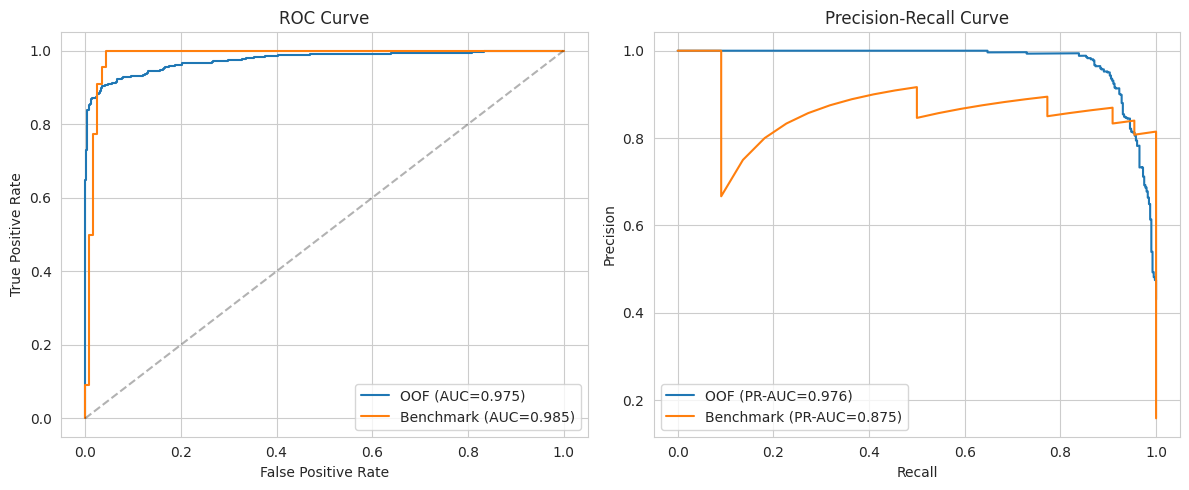

In [7]:
#@title # 8. ROC and Precision-Recall curves (OOF vs Benchmark)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr_oof, tpr_oof, _ = roc_curve(y_train_full, oof_proba)
fpr_bench, tpr_bench, _ = roc_curve(y_bench, y_bench_proba)
axes[0].plot(fpr_oof, tpr_oof, label=f"OOF (AUC={roc_auc_score(y_train_full, oof_proba):.3f})")
axes[0].plot(fpr_bench, tpr_bench, label=f"Benchmark (AUC={bench_metrics['auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

prec_oof, rec_oof, _ = precision_recall_curve(y_train_full, oof_proba)
prec_bench, rec_bench, _ = precision_recall_curve(y_bench, y_bench_proba)
axes[1].plot(rec_oof, prec_oof, label=f"OOF (PR-AUC={average_precision_score(y_train_full, oof_proba):.3f})")
axes[1].plot(rec_bench, prec_bench, label=f"Benchmark (PR-AUC={bench_metrics['pr_auc']:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "roc_pr_curves.png"), dpi=600)
plt.show()

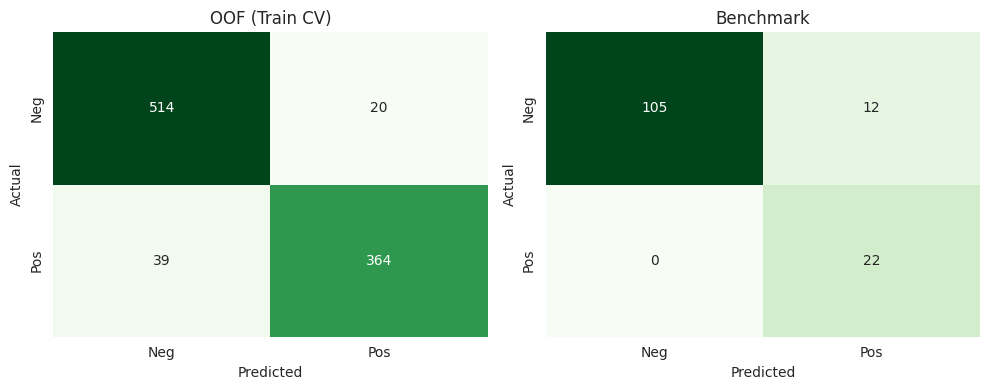

In [8]:
#@title # 9. Confusion matrix heatmaps (OOF vs Benchmark)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_oof = confusion_matrix(y_train_full, oof_pred)
cm_bench_ = confusion_matrix(y_bench, y_bench_pred)

for ax, cm, title in zip(axes, [cm_oof, cm_bench_], ["OOF (Train CV)", "Benchmark"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
                xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "confusion_matrices.png"), dpi=600)
plt.show()

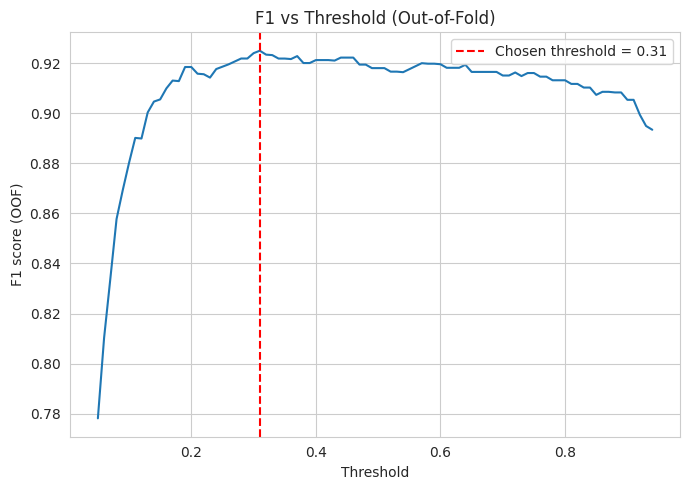

In [9]:
#@title # 10. F1 score vs threshold (OOF)
plt.figure(figsize=(7, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color="red", linestyle="--",
            label=f"Chosen threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 score (OOF)")
plt.title("F1 vs Threshold (Out-of-Fold)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "f1_vs_threshold.png"), dpi=600)
plt.show()

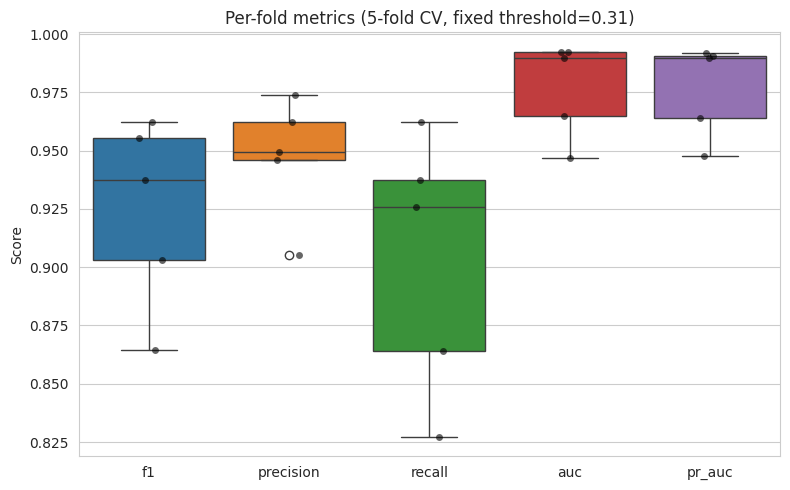

            f1  precision    recall       auc    pr_auc
mean  0.924631   0.947449  0.903457  0.977242  0.976745
std   0.040679   0.026012  0.055929  0.020643  0.019907


In [10]:
#@title # 11. Per-fold metrics with best hyperparameters (multi-metric)
# The hyperparameter search earlier only tracked F1 per fold. Here we
# re-run CV with the chosen best_params and best_threshold (using the same
# calibrated build_rf() as everywhere else), recording every metric per
# fold so we can see variance across folds, not just the mean.

fold_metrics = {"f1": [], "precision": [], "recall": [], "auc": [], "pr_auc": []}

for tr_idx, va_idx in skf.split(X_train_full, y_train_full):
    model = build_rf(best_params)
    model.fit(X_train_full[tr_idx], y_train_full[tr_idx])
    proba = model.predict_proba(X_train_full[va_idx])[:, 1]
    pred = (proba >= best_threshold).astype(int)

    fold_metrics["f1"].append(f1_score(y_train_full[va_idx], pred, zero_division=0))
    fold_metrics["precision"].append(precision_score(y_train_full[va_idx], pred, zero_division=0))
    fold_metrics["recall"].append(recall_score(y_train_full[va_idx], pred, zero_division=0))
    fold_metrics["auc"].append(roc_auc_score(y_train_full[va_idx], proba))
    fold_metrics["pr_auc"].append(average_precision_score(y_train_full[va_idx], proba))

fold_metrics_df = pd.DataFrame(fold_metrics)
fold_metrics_df.to_csv(os.path.join(MODEL_OUT_DIR, "cv_fold_metrics.csv"), index=False)

plt.figure(figsize=(8, 5))
sns.boxplot(data=fold_metrics_df)
sns.stripplot(data=fold_metrics_df, color="black", size=5, alpha=0.6)
plt.ylabel("Score")
plt.title(f"Per-fold metrics ({N_FOLDS}-fold CV, fixed threshold={best_threshold:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "cv_fold_metrics_boxplot.png"), dpi=600)
plt.show()

print(fold_metrics_df.describe().loc[["mean", "std"]])

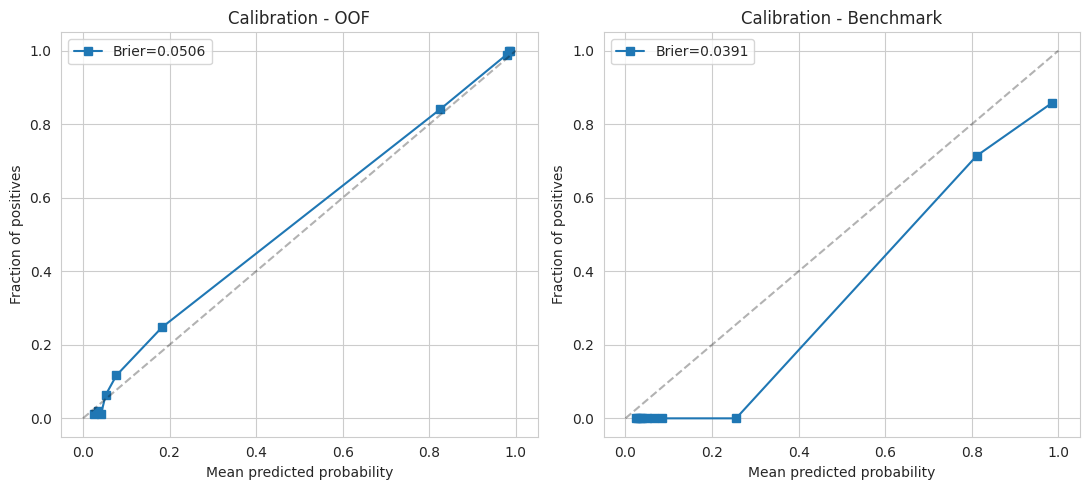

In [11]:
#@title # 12. Calibration curve & Brier score
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, proba, y_true, title in zip(
    axes, [oof_proba, y_bench_proba], [y_train_full, y_bench], ["OOF", "Benchmark"]
):
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "s-", label=f"Brier={brier_score_loss(y_true, proba):.4f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Calibration - {title}")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "calibration_curves.png"), dpi=600)
plt.show()

False Positives: 12
                                   sequence  pred_proba  seq_len
MKFGKFVLLAASTALAVVGLGGPAAADSTPQAQPSIIGGS...    0.340350      238
MTLTSTLRRQTRTTATATVLAAAAALALCAAPASAQQTGP...    0.988748      293
MHLPRSRWDIPFKEETTMTHHFSVRALLAAGALLASAAVS...    0.962132      304
MVRSMRSRVVAAAVACAMSGAQFAGTTAVMTLATTHAATA...    0.311396      370
MARTMRSRVVAGAVACAMSIAPFAGTTAVMTLATTHAAMA...    0.316830      364
MFQRVWALTAALMLMLSLGATSSHAAQNPHERGPDPSNSY...    0.979940      284
MKIIYPLAVLFLITSLAPNTIFAQCEDVTIESLTNPGPYE...    0.381619      365
MKRRLIAYSIAALAISATAVALPTGVASAAPCSDVDVSFA...    0.679587      216
MVRSMRSRVVAAAVACAMSGAQFAGTTAVMTLATTHAATA...    0.311308      370
MGLAIAAAAVFSLPGVATATEPTGGVQPNIVGGGNATQVY...    0.422037      241
MSTASQTYSPWDIRATAGLSPVATCLILIAMGPSCAKILS...    0.331301      428
MQSSTPRSTRRRIGALVAGAVLAGGTLTSSPALAAPSGGA...    0.496506      641

False Negatives: 0
Empty DataFrame
Columns: [sequence, pred_proba, seq_len]
Index: []


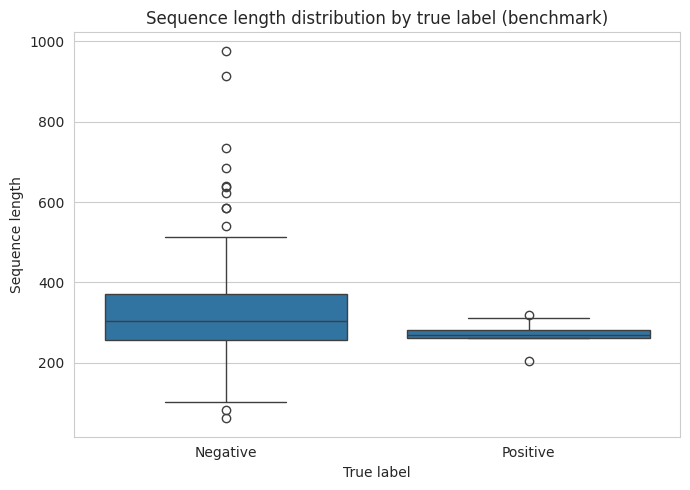

In [12]:
#@title # 13. Error analysis on the benchmark set
df_bench_result = df_bench.copy().reset_index(drop=True)
df_bench_result["pred_proba"] = y_bench_proba
df_bench_result["pred_label"] = y_bench_pred
df_bench_result["seq_len"] = df_bench_result["sequence"].str.len()

false_pos = df_bench_result[(df_bench_result["label"] == 0) & (df_bench_result["pred_label"] == 1)]
false_neg = df_bench_result[(df_bench_result["label"] == 1) & (df_bench_result["pred_label"] == 0)]

print(f"False Positives: {len(false_pos)}")
print(false_pos[["sequence", "pred_proba", "seq_len"]].assign(
    sequence=lambda d: d["sequence"].str[:40] + "..."
).to_string(index=False))

print(f"\nFalse Negatives: {len(false_neg)}")
print(false_neg[["sequence", "pred_proba", "seq_len"]].assign(
    sequence=lambda d: d["sequence"].str[:40] + "..."
).to_string(index=False))

df_bench_result.to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_predictions_detailed.csv"), index=False)

plt.figure(figsize=(7, 5))
sns.boxplot(x="label", y="seq_len", data=df_bench_result)
plt.xticks([0, 1], ["Negative", "Positive"])
plt.xlabel("True label")
plt.ylabel("Sequence length")
plt.title("Sequence length distribution by true label (benchmark)")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "seq_len_by_label.png"), dpi=600)
plt.show()

In [13]:
#@title # 14. Bootstrap confidence intervals for benchmark metrics
def bootstrap_metric(y_true, values, metric_fn, n_boot=2000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], values[idx]))
    return np.mean(scores), np.percentile(scores, [2.5, 97.5])

metrics_to_bootstrap = {
    "f1": (f1_score, y_bench_pred),
    "precision": (precision_score, y_bench_pred),
    "recall": (recall_score, y_bench_pred),
    "auc": (roc_auc_score, y_bench_proba),
    "pr_auc": (average_precision_score, y_bench_proba),
}

print("Benchmark metrics with 95% bootstrap CI (n_boot=2000):")
ci_results = {}
for name, (fn, vals) in metrics_to_bootstrap.items():
    mean, (lo, hi) = bootstrap_metric(y_bench, vals, fn)
    ci_results[name] = {"mean": mean, "ci_low": lo, "ci_high": hi}
    print(f"  {name:<10}: {mean:.4f}  [{lo:.4f}, {hi:.4f}]")

pd.DataFrame(ci_results).T.to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_metrics_bootstrap_ci.csv"))

Benchmark metrics with 95% bootstrap CI (n_boot=2000):
  f1        : 0.7838  [0.6498, 0.8937]
  precision : 0.6488  [0.4813, 0.8078]
  recall    : 1.0000  [1.0000, 1.0000]
  auc       : 0.9850  [0.9636, 0.9993]
  pr_auc    : 0.8843  [0.7169, 0.9967]


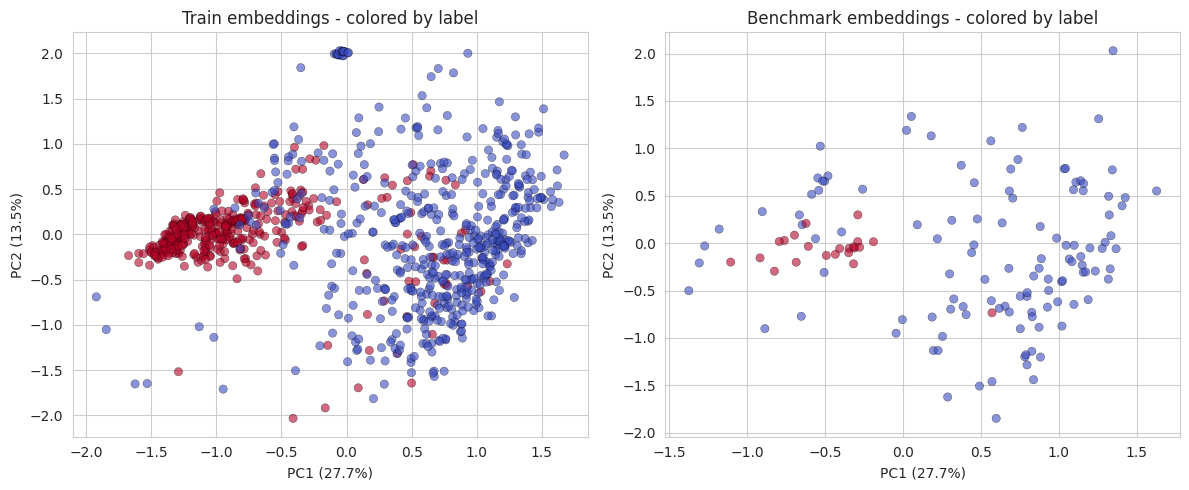

In [14]:
#@title # 15. PCA visualization of ESM-2 embeddings
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_full)
X_bench_pca = pca.transform(X_bench)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, X_pca, y, title in zip(axes, [X_train_pca, X_bench_pca], [y_train_full, y_bench], ["Train", "Benchmark"]):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.6, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(f"{title} embeddings - colored by label")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "embedding_pca.png"), dpi=600)
plt.show()

Found 3 underlying RandomForest estimator(s) inside the calibration wrapper.
shap_values_pos shape: (937, 640)


/tmp/ipykernel_2431/3787515088.py:57: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_pos, X_train_full, show=False, max_display=20)


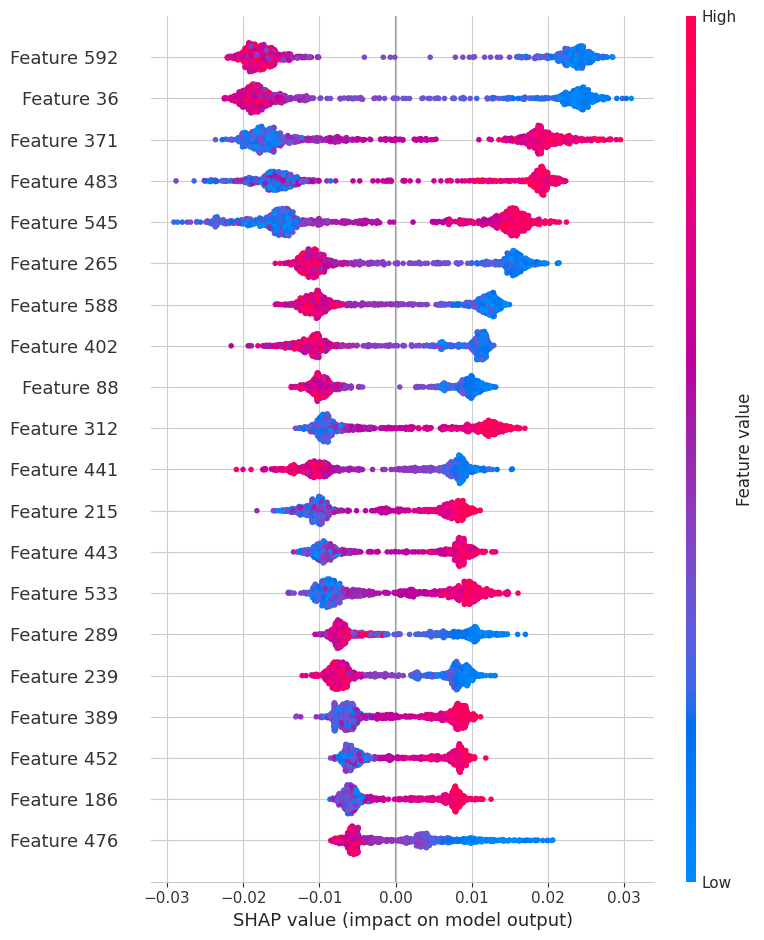

 embedding_dim  mean_abs_shap  rf_gini_importance
           592       0.019776            0.039134
            36       0.019140            0.039826
           371       0.016794            0.035237
           483       0.016660            0.033786
           545       0.014804            0.026930
           265       0.012094            0.024541
           588       0.010500            0.020153
           402       0.010475            0.018807
            88       0.009500            0.017177
           312       0.009385            0.018235
           441       0.009000            0.013683
           215       0.008697            0.014501
           443       0.008666            0.016354
           533       0.008123            0.013325
           289       0.007674            0.013266
           239       0.007398            0.014012
           389       0.006696            0.016431
           452       0.006307            0.015002
           186       0.006209            0.014937


In [15]:
#@title # 16. SHAP analysis - embedding-dimension level (model diagnostics)
# IMPORTANT CAVEAT:
# SHAP here explains the model in terms of the ~640 ESM-2 embedding
# dimensions, NOT individual amino acid residues. Embedding dimensions do
# not have a fixed, human-readable biological meaning, so this view is
# useful mainly as a MODEL DIAGNOSTIC (e.g. is the model relying on a
# handful of dominant dimensions, or spread across many?).
#
# For actual biological interpretation (which residues matter), see the
# in-silico mutagenesis section below -- that is the tool that answers
# the biological question.
#
# NOTE ON CALIBRATION: final_model is a CalibratedClassifierCV wrapping the
# Random Forest (see section 4). shap.TreeExplainer cannot read a
# CalibratedClassifierCV directly -- it only understands tree-based
# estimators, not the calibration wrapper on top. So we reach into the
# wrapper and pull out the underlying RandomForestClassifier(s) it fitted
# internally (one per calibration cv fold), run TreeExplainer on each, and
# average the SHAP values. This describes the RF's raw feature attributions
# before calibration is applied -- calibration only rescales the final
# probability, it doesn't change which embedding dimensions the trees split
# on, so this is still a faithful diagnostic of the underlying RF.

# Extract the base RandomForest estimator(s) from inside CalibratedClassifierCV.
# Attribute name differs across sklearn versions ("estimator" in newer
# versions, "base_estimator" in older ones), so we try both.
base_rf_estimators = []
for calibrated_clf in final_model.calibrated_classifiers_:
    if hasattr(calibrated_clf, "estimator"):
        base_rf_estimators.append(calibrated_clf.estimator)
    elif hasattr(calibrated_clf, "base_estimator"):
        base_rf_estimators.append(calibrated_clf.base_estimator)
    else:
        raise AttributeError("Could not find the underlying RF inside CalibratedClassifierCV.")

print(f"Found {len(base_rf_estimators)} underlying RandomForest estimator(s) inside the calibration wrapper.")

all_shap_values = []
for rf_est in base_rf_estimators:
    explainer = shap.TreeExplainer(rf_est)
    sv = explainer.shap_values(X_train_full)

    # Same defensive handling as before: list [class0, class1] vs 3D array vs plain 2D
    if isinstance(sv, list):
        sv_pos = sv[1]
    elif isinstance(sv, np.ndarray) and sv.ndim == 3:
        sv_pos = sv[:, :, 1]
    else:
        sv_pos = sv
    all_shap_values.append(sv_pos)

shap_values_pos = np.mean(all_shap_values, axis=0)
print(f"shap_values_pos shape: {shap_values_pos.shape}")
assert shap_values_pos.ndim == 2, "shap_values_pos must be 2D (n_samples, n_features)"

plt.figure()
shap.summary_plot(shap_values_pos, X_train_full, show=False, max_display=20)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "shap_summary_embedding_dims.png"), dpi=600, bbox_inches="tight")
plt.show()

mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
top_dims = np.argsort(mean_abs_shap)[::-1][:20]

# Gini importance averaged across the underlying RF estimators too, for a
# fair comparison against the averaged SHAP values above.
mean_rf_importance = np.mean([est.feature_importances_ for est in base_rf_estimators], axis=0)

importance_df = pd.DataFrame({
    "embedding_dim": top_dims,
    "mean_abs_shap": mean_abs_shap[top_dims],
    "rf_gini_importance": mean_rf_importance[top_dims],
})
print(importance_df.to_string(index=False))
importance_df.to_csv(os.path.join(MODEL_OUT_DIR, "shap_top_embedding_dims.csv"), index=False)

Fetching IsPETase (A0A0K8P6T7) from UniProt...
  Length: 290 aa
  Base predicted probability: 0.9831
  Known catalytic triad: [160, 206, 237]
    position 160: rank 281/290 (top 96.9%), delta=-0.00164
    position 206: rank 247/290 (top 85.2%), delta=-0.00033
    position 237: rank 170/290 (top 58.6%), delta=0.00023
  Top-15 predicted important positions: [21, 26, 49, 63, 69, 70, 76, 97, 106, 140, 174, 195, 257, 273, 289]
  Overlap with catalytic triad (top-15): [] (0/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model2_esm2_rf/reference_mutagenesis_ispetase_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model2_esm2_rf/reference_mutagenesis_ispetase_full_scan.csv

  Alanine substitution vs native <mask> substitution (catalytic triad only):
 position residue  alanine_delta  mask_delta
      160       S      -0.001639   -0.000637
      206       D      -0.000333   -0.000553
      237       H       0.000226

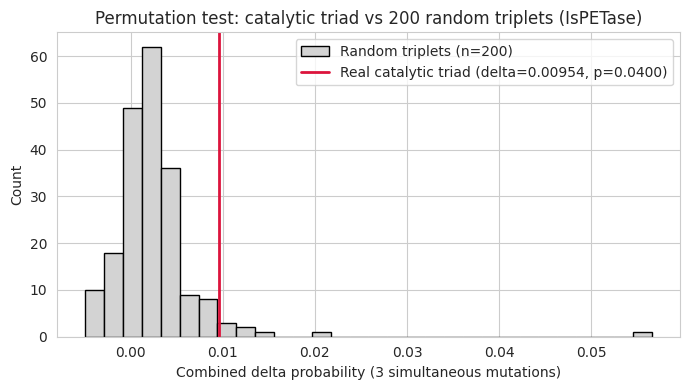


  Running windowed mutagenesis scan (window_size=7)... this runs ~290 more forward passes, so it takes a bit.
  Window-centered rank of catalytic positions (window_size=7):
    position 160: window-rank 87/290 (top 30.0%), window_delta=0.01136 (vs single-residue delta=-0.00164)
    position 206: window-rank 262/290 (top 90.3%), window_delta=-0.00096 (vs single-residue delta=-0.00033)
    position 237: window-rank 243/290 (top 83.8%), window_delta=0.00078 (vs single-residue delta=0.00023)


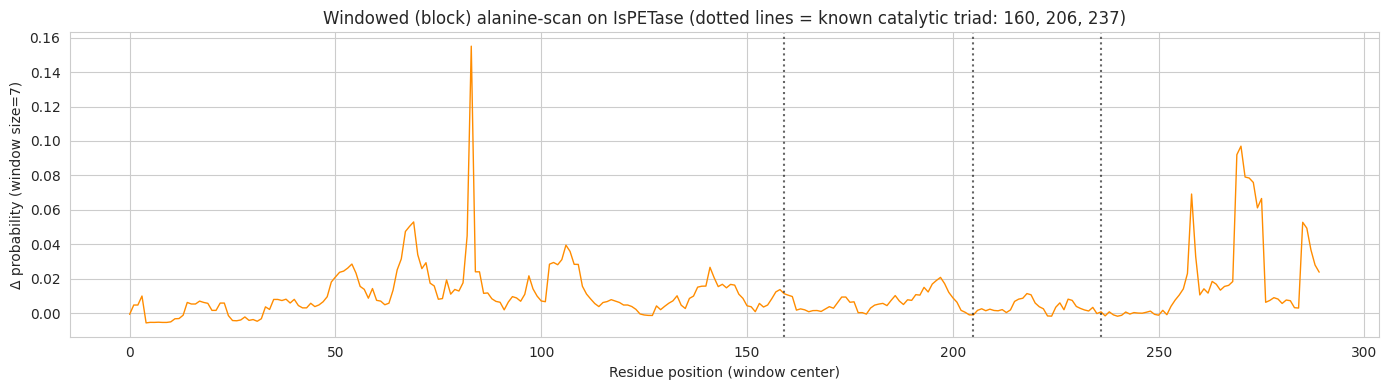

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model2_esm2_rf/reference_mutagenesis_ispetase_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model2_esm2_rf/reference_mutagenesis_ispetase_windowed_scan.csv


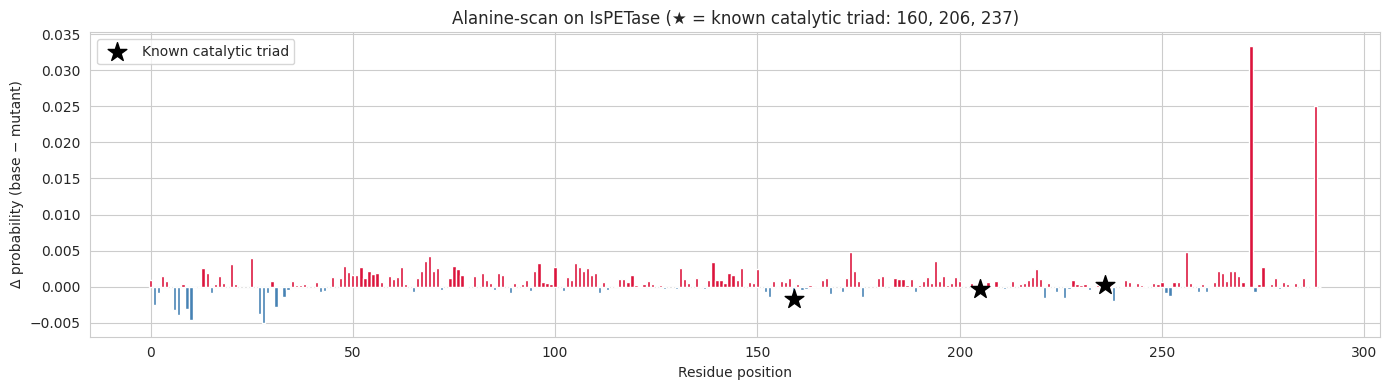

Fetching LCC (G9BY57) from UniProt...
  Length: 293 aa
  Base predicted probability: 0.9892
  Known catalytic triad: [165, 210, 242]
    position 165: rank 16/293 (top 5.5%), delta=0.00027
    position 210: rank 101/293 (top 34.5%), delta=0.00009
    position 242: rank 8/293 (top 2.7%), delta=0.00037
  Top-15 predicted important positions: [3, 7, 9, 30, 33, 38, 79, 81, 155, 242, 259, 267, 275, 279, 292]
  Overlap with catalytic triad (top-15): [242] (1/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model2_esm2_rf/reference_mutagenesis_lcc_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model2_esm2_rf/reference_mutagenesis_lcc_full_scan.csv

  Alanine substitution vs native <mask> substitution (catalytic triad only):
 position residue  alanine_delta  mask_delta
      165       S       0.000274    0.000130
      210       D       0.000086   -0.000043
      242       H       0.000374    0.000130

  Combined t

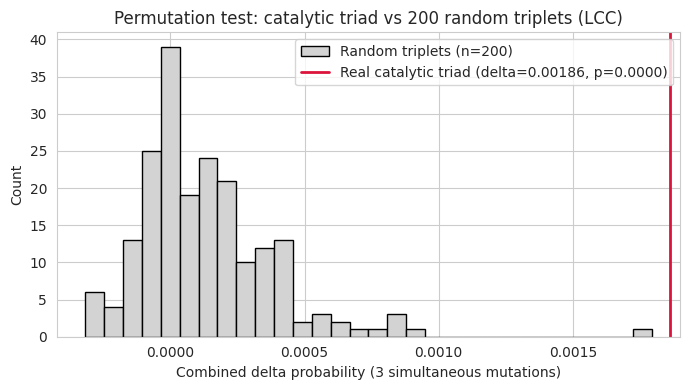


  Running windowed mutagenesis scan (window_size=7)... this runs ~293 more forward passes, so it takes a bit.
  Window-centered rank of catalytic positions (window_size=7):
    position 165: window-rank 32/293 (top 10.9%), window_delta=0.00157 (vs single-residue delta=0.00027)
    position 210: window-rank 185/293 (top 63.1%), window_delta=0.00020 (vs single-residue delta=0.00009)
    position 242: window-rank 31/293 (top 10.6%), window_delta=0.00163 (vs single-residue delta=0.00037)


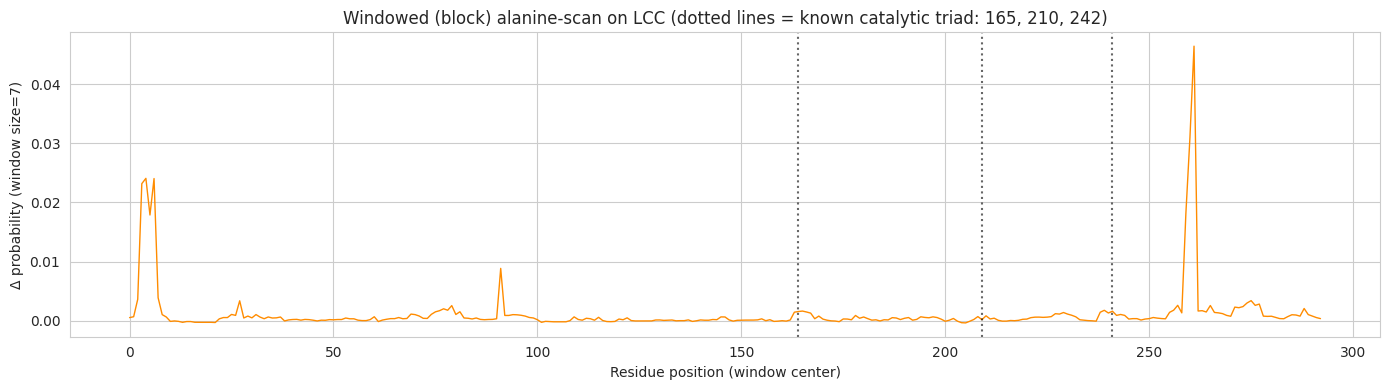

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model2_esm2_rf/reference_mutagenesis_lcc_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model2_esm2_rf/reference_mutagenesis_lcc_windowed_scan.csv


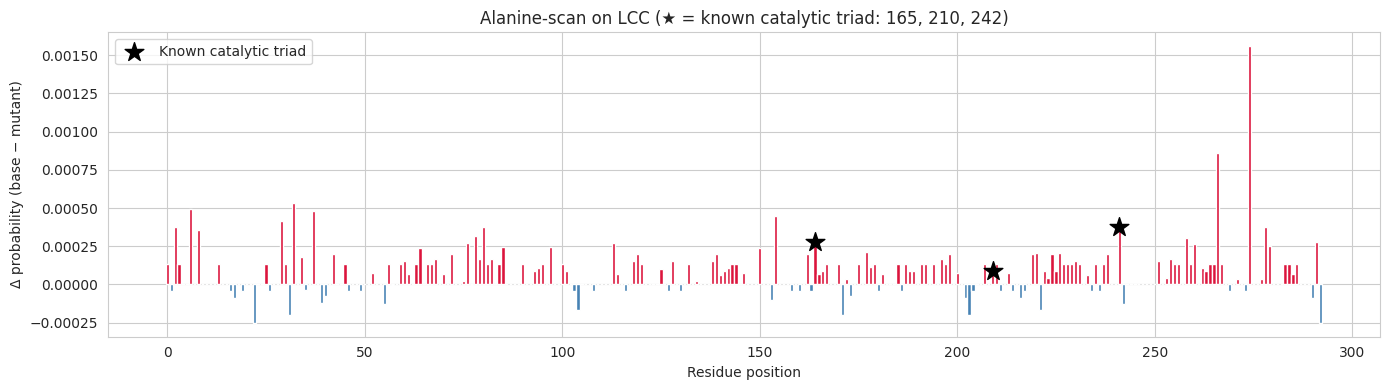

Fetching CalB_negative_control (P41365) from UniProt...
  Length: 342 aa
  Base predicted probability: 0.5750
  Known catalytic triad: [130, 212, 249]
    position 130: rank 74/342 (top 21.6%), delta=0.05027
    position 212: rank 193/342 (top 56.4%), delta=0.03063
    position 249: rank 16/342 (top 4.7%), delta=0.08314
  Top-15 predicted important positions: [24, 25, 47, 131, 134, 147, 193, 297, 302, 303, 305, 310, 313, 336, 342]
  Overlap with catalytic triad (top-15): [] (0/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model2_esm2_rf/reference_mutagenesis_calb_negative_control_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model2_esm2_rf/reference_mutagenesis_calb_negative_control_full_scan.csv

  Alanine substitution vs native <mask> substitution (catalytic triad only):
 position residue  alanine_delta  mask_delta
      130       S       0.050269    0.019789
      212       D       0.030632    0.0270

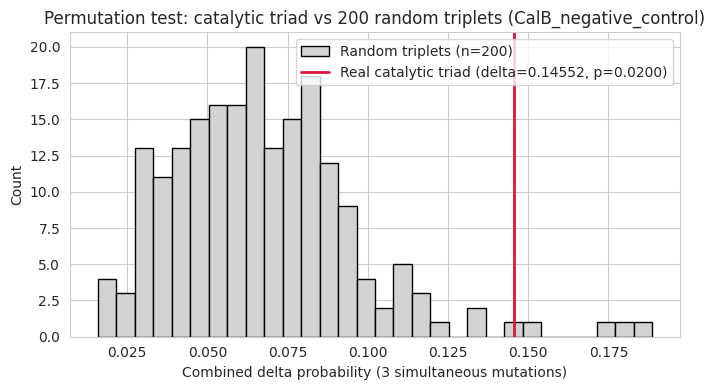


  Running windowed mutagenesis scan (window_size=7)... this runs ~342 more forward passes, so it takes a bit.
  Window-centered rank of catalytic positions (window_size=7):
    position 130: window-rank 25/342 (top 7.3%), window_delta=0.25588 (vs single-residue delta=0.05027)
    position 212: window-rank 232/342 (top 67.8%), window_delta=0.12534 (vs single-residue delta=0.03063)
    position 249: window-rank 224/342 (top 65.5%), window_delta=0.12886 (vs single-residue delta=0.08314)


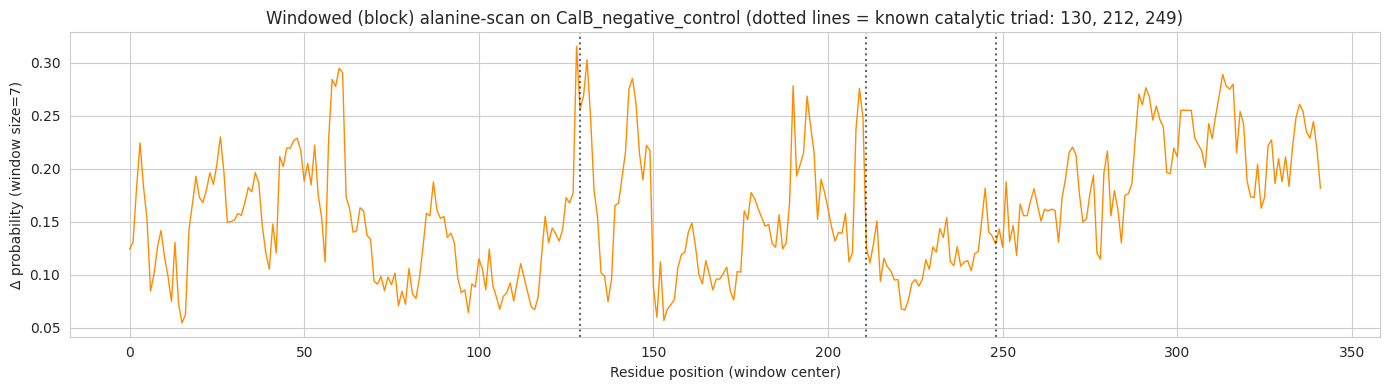

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model2_esm2_rf/reference_mutagenesis_calb_negative_control_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model2_esm2_rf/reference_mutagenesis_calb_negative_control_windowed_scan.csv


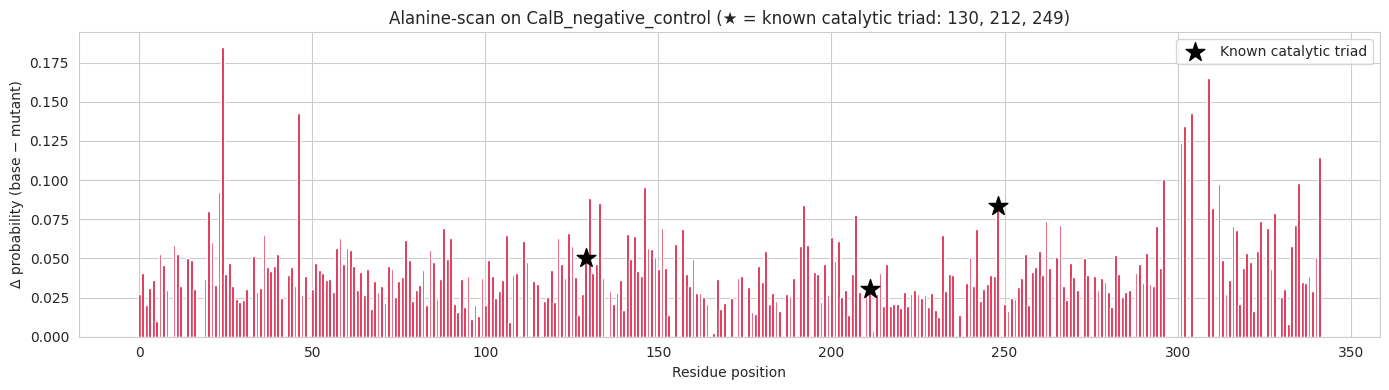


Saved reference scan results to /content/drive/MyDrive/InterPET/models/model2_esm2_rf/reference_mutagenesis_results.pkl


In [9]:
#@title # 17. Fixed reference-sequence scan -- IsPETase active site (valid cross-model comparison)
# This section replaces the old "highest-confidence TP" demo (which picked a
# different, model-dependent sequence every time and was not usable for
# cross-model comparison). Instead we scan a FIXED reference sequence, chosen
# independently of any model's predictions, with a catalytic site already
# confirmed in the literature: IsPETase (Ideonella sakaiensis PETase),
# UniProt A0A0K8P6T7.
#
#   Catalytic triad: Ser160, Asp206, His237
#   (Yoshida et al. 2016, Science; Han et al. 2017, Nat. Commun., PDB 5XJH --
#   confirmed structurally and by site-directed mutagenesis; any substitution
#   at these positions abolishes catalytic activity.)
#
# Because every model notebook scans this exact same sequence, the top
# residues each model highlights can be directly compared, and checked
# against a real, experimentally-confirmed active site -- not just against
# each other.

!pip install -q openpyxl
import requests


@torch.no_grad()
def get_embedding_single(sequence, max_len=1022):
    seq = sequence[:max_len]
    inputs = esm2_tokenizer([seq], return_tensors="pt", truncation=True, max_length=max_len + 2)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    out = esm2_model(**inputs)
    mask = inputs["attention_mask"].unsqueeze(-1)
    mean_pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
    return mean_pooled.cpu().numpy()[0]


def mutagenesis_scan(sequence, model, mutate_to="A"):
    """Return (base_proba, per_position_deltas) for a single sequence.
    delta[i] = base_proba - proba_after_mutating_position_i_to_`mutate_to`.
    A positive delta means residue i supports the positive-class prediction."""
    seq = sequence.strip().upper()
    base_emb = get_embedding_single(seq).reshape(1, -1)
    base_proba = model.predict_proba(base_emb)[0, 1]

    deltas = np.zeros(len(seq))
    for i, aa in enumerate(seq):
        if aa == mutate_to:
            deltas[i] = 0.0
            continue
        mutant_seq = seq[:i] + mutate_to + seq[i + 1:]
        mutant_emb = get_embedding_single(mutant_seq).reshape(1, -1)
        mutant_proba = model.predict_proba(mutant_emb)[0, 1]
        deltas[i] = base_proba - mutant_proba

    return base_proba, deltas


def windowed_mutagenesis_scan(sequence, model, window_size=7, mutate_to="A"):
    """Slide a contiguous window across the sequence, mutating the WHOLE
    window to alanine at once (rather than one residue at a time), and
    record the resulting delta at the window's center position.
    This can reveal regions that matter collectively even when no single
    residue inside them stands out on its own (i.e. individual mutations
    are below the mean-pooling noise floor, but a whole disrupted block
    is not)."""
    seq = sequence.strip().upper()
    n = len(seq)
    half = window_size // 2

    base_emb = get_embedding_single(seq).reshape(1, -1)
    base_proba = model.predict_proba(base_emb)[0, 1]

    window_deltas = np.zeros(n)
    for center in range(n):
        start = max(0, center - half)
        end = min(n, center + half + 1)
        mutant_seq = seq[:start] + mutate_to * (end - start) + seq[end:]
        mutant_emb = get_embedding_single(mutant_seq).reshape(1, -1)
        mutant_proba = model.predict_proba(mutant_emb)[0, 1]
        window_deltas[center] = base_proba - mutant_proba

    return base_proba, window_deltas


REFERENCE_SEQUENCES = {
    "IsPETase": {
        "uniprot_id": "A0A0K8P6T7",
        "source": "Yoshida et al. 2016 Science; Han et al. 2017 Nat Commun (PDB 5XJH)",
        "catalytic_triad_positions": [160, 206, 237],  # Ser160, Asp206, His237 (1-indexed)
        "expected_residues": {160: "S", 206: "D", 237: "H"},
        "is_petase": True,
    },
    "LCC": {
        "uniprot_id": "G9BY57",
        "source": "Sulaiman et al. 2012 Appl Environ Microbiol; Tournier et al. 2020 Nature (PDB 4EB0)",
        "catalytic_triad_positions": [165, 210, 242],  # Ser165, Asp210, His242 (1-indexed)
        "expected_residues": {165: "S", 210: "D", 242: "H"},
        "is_petase": True,
    },
    "CalB_negative_control": {
        "uniprot_id": "P41365",
        "source": "Uppenberg et al. 1994 Structure (PDB 1TCA) -- Candida antarctica Lipase B, "
                   "NOT PET-active; same catalytic mechanism/fold family as PETases, used as "
                   "a functional-specificity negative control",
        "catalytic_triad_positions": [130, 212, 249],  # Ser130, Asp212, His249 (1-indexed)
        "expected_residues": {130: "S", 212: "D", 249: "H"},
        "is_petase": False,
    },
}


def fetch_uniprot_sequence(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    lines = resp.text.strip().split("\n")
    return "".join(lines[1:])  # drop the ">header" line


reference_scan_results = {}

for ref_name, ref_info in REFERENCE_SEQUENCES.items():
    print(f"Fetching {ref_name} ({ref_info['uniprot_id']}) from UniProt...")
    ref_seq = fetch_uniprot_sequence(ref_info["uniprot_id"])
    print(f"  Length: {len(ref_seq)} aa")

    base_p, deltas = mutagenesis_scan(ref_seq, final_model)
    print(f"  Base predicted probability: {base_p:.4f}")

    top_n = 15
    order = np.argsort(deltas)[::-1]
    top_positions = set((order[:top_n] + 1).tolist())  # 1-indexed
    known_positions = set(ref_info["catalytic_triad_positions"])
    overlap = known_positions & top_positions

    rank_of = {pos: int(np.where(order == (pos - 1))[0][0]) + 1 for pos in known_positions}
    n_total = len(deltas)
    print(f"  Known catalytic triad: {sorted(known_positions)}")
    for pos in sorted(known_positions):
        pct_from_top = 100 * rank_of[pos] / n_total
        print(f"    position {pos}: rank {rank_of[pos]}/{n_total} (top {pct_from_top:.1f}%), delta={deltas[pos-1]:.5f}")
    print(f"  Top-{top_n} predicted important positions: {sorted(top_positions)}")
    print(f"  Overlap with catalytic triad (top-{top_n}): {sorted(overlap)} ({len(overlap)}/{len(known_positions)})")

    # ---- Export full per-residue delta table to Excel + CSV ----
    full_scan_df = pd.DataFrame({
        "position": np.arange(1, len(ref_seq) + 1),
        "residue": list(ref_seq),
        "delta_proba": deltas,
        "is_known_catalytic_residue": [p in known_positions for p in range(1, len(ref_seq) + 1)],
    }).sort_values("delta_proba", ascending=False).reset_index(drop=True)

    excel_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_full_scan.xlsx")
    csv_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_full_scan.csv")
    full_scan_df.to_excel(excel_path, index=False, sheet_name="alanine_scan")
    full_scan_df.to_csv(csv_path, index=False)
    print(f"  Saved full per-residue delta table to {excel_path}")
    print(f"  Saved full per-residue delta table to {csv_path}")

    # ---- Variation 1: mask-token substitution vs alanine, at the 3 known positions only ----
    mask_token_id = esm2_tokenizer.mask_token_id

    base_inputs = esm2_tokenizer([ref_seq[:1022]], return_tensors="pt", truncation=True, max_length=1024)
    base_inputs = {k: v.to(device) for k, v in base_inputs.items()}

    @torch.no_grad()
    def embed_from_input_ids(input_ids, attention_mask):
        out = esm2_model(input_ids=input_ids, attention_mask=attention_mask)
        m = attention_mask.unsqueeze(-1)
        return ((out.last_hidden_state * m).sum(1) / m.sum(1)).cpu().numpy()[0]

    mask_comparison = []
    for pos in sorted(known_positions):
        token_idx = pos  # index 0 is <cls>, so residue `pos` (1-indexed) sits at token index `pos`
        mutant_ids = base_inputs["input_ids"].clone()
        mutant_ids[0, token_idx] = mask_token_id
        mutant_emb = embed_from_input_ids(mutant_ids, base_inputs["attention_mask"]).reshape(1, -1)
        mask_proba = final_model.predict_proba(mutant_emb)[0, 1]
        mask_delta = base_p - mask_proba
        mask_comparison.append({
            "position": pos,
            "residue": ref_seq[pos - 1],
            "alanine_delta": deltas[pos - 1],
            "mask_delta": mask_delta,
        })

    mask_comparison_df = pd.DataFrame(mask_comparison)
    print("\n  Alanine substitution vs native <mask> substitution (catalytic triad only):")
    print(mask_comparison_df.to_string(index=False))

    # ---- Variation 2: combined (simultaneous) triple mutation vs sum of individual deltas ----
    seq_list = list(ref_seq)
    for pos in known_positions:
        seq_list[pos - 1] = "A"
    combined_mutant_seq = "".join(seq_list)
    combined_emb = get_embedding_single(combined_mutant_seq).reshape(1, -1)
    combined_proba = final_model.predict_proba(combined_emb)[0, 1]
    combined_delta = base_p - combined_proba
    sum_individual_deltas = sum(deltas[pos - 1] for pos in known_positions)

    print(f"\n  Combined triple-mutation (all 3 catalytic residues -> Ala simultaneously):")
    print(f"    proba after combined mutation : {combined_proba:.4f}")
    print(f"    combined delta                : {combined_delta:.5f}")
    print(f"    sum of individual deltas       : {sum_individual_deltas:.5f}")
    print(f"    synergy (combined - sum)        : {combined_delta - sum_individual_deltas:.5f}")

    # ---- Variation 2b: permutation test for the combined-mutation synergy ----
    # Is the combined delta actually special, or would mutating ANY random
    # triplet of positions simultaneously tend to produce a similarly large
    # delta (since disturbing 3 positions at once is inherently a bigger
    # perturbation than disturbing 1)? We build a null distribution from
    # random triplets (excluding the real triad) and see where the real
    # triad's combined delta falls within it.
    n_permutations = 200
    rng = np.random.default_rng(RANDOM_SEED)
    all_positions = np.arange(1, len(ref_seq) + 1)
    candidate_positions = np.setdiff1d(all_positions, list(known_positions))

    null_deltas = np.zeros(n_permutations)
    for p_i in range(n_permutations):
        rand_positions = rng.choice(candidate_positions, size=len(known_positions), replace=False)
        seq_list_rand = list(ref_seq)
        for pos in rand_positions:
            seq_list_rand[pos - 1] = "A"
        rand_mutant_seq = "".join(seq_list_rand)
        rand_emb = get_embedding_single(rand_mutant_seq).reshape(1, -1)
        rand_proba = final_model.predict_proba(rand_emb)[0, 1]
        null_deltas[p_i] = base_p - rand_proba
        if (p_i + 1) % 50 == 0:
            print(f"    permutation {p_i + 1}/{n_permutations}...")

    p_value = float(np.mean(null_deltas >= combined_delta))
    z_score = float((combined_delta - null_deltas.mean()) / (null_deltas.std() + 1e-12))

    print(f"\n  Permutation test (n={n_permutations} random triplets of positions, "
          f"excluding the real catalytic triad):")
    print(f"    null distribution -- mean={null_deltas.mean():.5f}, std={null_deltas.std():.5f}, "
          f"max={null_deltas.max():.5f}")
    print(f"    observed combined delta (real catalytic triad): {combined_delta:.5f}")
    print(f"    empirical p-value (P[null >= observed]): {p_value:.4f}")
    print(f"    z-score: {z_score:.3f}")

    plt.figure(figsize=(7, 4))
    plt.hist(null_deltas, bins=30, color="lightgray", edgecolor="black", label=f"Random triplets (n={n_permutations})")
    plt.axvline(combined_delta, color="crimson", linewidth=2,
                label=f"Real catalytic triad (delta={combined_delta:.5f}, p={p_value:.4f})")
    plt.xlabel("Combined delta probability (3 simultaneous mutations)")
    plt.ylabel("Count")
    plt.title(f"Permutation test: catalytic triad vs {n_permutations} random triplets ({ref_name})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_permutation_test.png"), dpi=600)
    plt.show()

    pd.DataFrame({"null_delta": null_deltas}).to_csv(
        os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_permutation_null.csv"), index=False
    )

    # ---- Variation 3: windowed/block mutagenesis ----
    window_size = 7
    print(f"\n  Running windowed mutagenesis scan (window_size={window_size})... "
          f"this runs ~{len(ref_seq)} more forward passes, so it takes a bit.")
    _, window_deltas = windowed_mutagenesis_scan(ref_seq, final_model, window_size=window_size)

    window_order = np.argsort(window_deltas)[::-1]
    print(f"  Window-centered rank of catalytic positions (window_size={window_size}):")
    for pos in sorted(known_positions):
        w_rank = int(np.where(window_order == (pos - 1))[0][0]) + 1
        w_pct = 100 * w_rank / n_total
        print(f"    position {pos}: window-rank {w_rank}/{n_total} (top {w_pct:.1f}%), "
              f"window_delta={window_deltas[pos-1]:.5f} (vs single-residue delta={deltas[pos-1]:.5f})")

    plt.figure(figsize=(14, 4))
    plt.plot(range(len(window_deltas)), window_deltas, color="darkorange", linewidth=1)
    for pos in known_positions:
        plt.axvline(pos - 1, color="black", linestyle=":", alpha=0.6)
    plt.xlabel("Residue position (window center)")
    plt.ylabel(f"\u0394 probability (window size={window_size})")
    plt.title(f"Windowed (block) alanine-scan on {ref_name} "
              f"(dotted lines = known catalytic triad: {', '.join(str(p) for p in sorted(known_positions))})")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed.png"), dpi=600)
    plt.show()

    window_scan_df = pd.DataFrame({
        "position": np.arange(1, len(ref_seq) + 1),
        "residue": list(ref_seq),
        "window_delta_proba": window_deltas,
        "single_residue_delta_proba": deltas,
        "is_known_catalytic_residue": [p in known_positions for p in range(1, len(ref_seq) + 1)],
    }).sort_values("window_delta_proba", ascending=False).reset_index(drop=True)
    window_excel_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed_scan.xlsx")
    window_csv_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed_scan.csv")
    window_scan_df.to_excel(window_excel_path, index=False, sheet_name=f"window{window_size}_scan")
    window_scan_df.to_csv(window_csv_path, index=False)
    print(f"  Saved windowed scan table to {window_excel_path}")
    print(f"  Saved windowed scan table to {window_csv_path}")

    reference_scan_results[ref_name] = {
        "sequence": ref_seq,
        "base_proba": base_p,
        "deltas": deltas,
        "window_deltas": window_deltas,
        "window_size": window_size,
        "top_positions": sorted(top_positions),
        "known_catalytic_triad": sorted(known_positions),
        "overlap_with_catalytic_triad": sorted(overlap),
        "rank_of_known_positions": rank_of,
        "mask_vs_alanine_comparison": mask_comparison,
        "combined_triple_mutation_delta": combined_delta,
        "sum_of_individual_deltas": sum_individual_deltas,
        "permutation_test_null_deltas": null_deltas,
        "permutation_test_p_value": p_value,
        "permutation_test_z_score": z_score,
    }

    plt.figure(figsize=(14, 4))
    colors = ["crimson" if d > 0 else "steelblue" for d in deltas]
    plt.bar(range(len(deltas)), deltas, color=colors)
    for pos in known_positions:
        plt.scatter([pos - 1], [deltas[pos - 1]], marker="*", s=200,
                    color="black", zorder=5,
                    label="Known catalytic triad" if pos == min(known_positions) else None)
    plt.xlabel("Residue position")
    plt.ylabel("\u0394 probability (base \u2212 mutant)")
    plt.title(f"Alanine-scan on {ref_name} (\u2605 = known catalytic triad: "
              f"{', '.join(str(p) for p in sorted(known_positions))})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}.png"), dpi=600)
    plt.show()

with open(os.path.join(MODEL_OUT_DIR, "reference_mutagenesis_results.pkl"), "wb") as f:
    pickle.dump(reference_scan_results, f)

print(f"\nSaved reference scan results to {MODEL_OUT_DIR}/reference_mutagenesis_results.pkl")

In [17]:
#@title # 18. Top-15 residues for the top-3 highest-confidence benchmark sequences
# Selection criterion here is purely the model's own predicted probability
# (base_proba on the benchmark set) -- the 3 sequences the model is most
# confident about, regardless of TP/FP/FN status. mutagenesis_scan() was
# already defined in the previous section, so it's reused as-is here.

top3_rows = np.argsort(y_bench_proba)[::-1][:3]
print(f"Top-3 benchmark rows by base_proba: {list(top3_rows)}")

excel_path = os.path.join(MODEL_OUT_DIR, "batch_mutagenesis_top15_top3rows.xlsx")
top15_summary = []

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for row in top3_rows:
        seq = df_bench.iloc[row]["sequence"]
        base_p, deltas = mutagenesis_scan(seq, final_model)

        top15_idx = np.argsort(deltas)[::-1][:15]
        row_df = pd.DataFrame({
            "position": top15_idx + 1,  # 1-indexed
            "residue": [seq[i] for i in top15_idx],
            "delta_proba": deltas[top15_idx],
        })
        row_df.insert(0, "benchmark_row", row)
        row_df.insert(1, "base_proba", base_p)

        sheet_name = f"row_{row}"[:31]  # Excel sheet name limit
        row_df.to_excel(writer, index=False, sheet_name=sheet_name)
        top15_summary.append(row_df)

        print(f"\nRow {row} (base_proba={base_p:.4f}) -- top 15 residues:")
        print(row_df[["position", "residue", "delta_proba"]].to_string(index=False))

print(f"\nSaved top-15 tables for top-3 benchmark rows to {excel_path}")

top15_summary_df = pd.concat(top15_summary, ignore_index=True)
top15_summary_df.to_csv(os.path.join(MODEL_OUT_DIR, "batch_mutagenesis_top15_top3rows.csv"), index=False)

Top-3 benchmark rows by base_proba: [np.int64(16), np.int64(2), np.int64(8)]

Row 16 (base_proba=0.9895) -- top 15 residues:
 position residue  delta_proba
      270       C     0.000298
      286       C     0.000180
      184       W     0.000120
      112       V     0.000120
       33       Y     0.000036
      122       D     0.000030
      237       H     0.000023
      227       K     0.000015
      249       K     0.000015
       17       V     0.000015
       82       F     0.000015
      257       R     0.000015
      188       K     0.000015
      158       H     0.000001
       38       D     0.000000

Row 2 (base_proba=0.9889) -- top 15 residues:
 position residue  delta_proba
      195       W     0.000733
      265       W     0.000700
      133       P     0.000594
      163       R     0.000579
      229       Y     0.000537
      123       T     0.000537
      276       Y     0.000522
      266       L     0.000510
      299       C     0.000498
      279       F     